# MM-Net — Verify & Reproduce (self-contained)
**A Physiologically Interpretable Multimodal Model for Joint Sleep Staging and Respiratory-Event
Detection in Subacute Ischemic Stroke**

Every number and figure below is **produced by executing the cell** on the iSLEEPS cohort:
the model, the training loop, the ten-fold cross-validation, the ablation grid and the analyses
are all defined and run inside this notebook. Nothing is read back from a precomputed result
file. Protocol: ten-fold **patient-independent** cross-validation on the fixed fold assignment
`make_folds(seed=42)`. The engineered per-epoch features (`data/mm_features/`) and the raw
event/AHI spreadsheets are the inputs; the extraction code is shown where relevant.

## 0. Setup

In [1]:
import os, sys, glob, json, re, warnings, time
import numpy as np
warnings.filterwarnings("ignore")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
if os.path.basename(os.getcwd()) == "revision":
    os.chdir("..")                       # run from repo root
sys.path.insert(0, os.path.abspath("processing"))
sys.path.insert(0, os.path.abspath("utils"))
import torch, torch.nn as nn
from sklearn.metrics import (accuracy_score, cohen_kappa_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
L, NC, EPS = 20, 5, 1e-12
CLS = ["W", "N1", "N2", "N3", "R"]
print("cwd:", os.getcwd(), "| device:", DEV,
      "|", torch.cuda.get_device_name(0) if DEV == "cuda" else "CPU")

cwd: D:\MOB-EEG | device: cuda | NVIDIA GeForce RTX 2060


## 1. Data
Per-epoch features were extracted once from the raw recordings (7 neural channels at 100 Hz to
188 EEG/EOG/EMG features; 7 cardiorespiratory channels at 25 Hz to 14 features). We load them
here and standardize per patient. SN28 (byte-identical to SN15) is dropped, giving N=99 for
staging; the respiratory task uses the N=96 with complete cardiorespiratory channels.

In [2]:
FE = "data/mm_features"
DUP = {28}
def load_data():
    data = {}
    for f in sorted(glob.glob(os.path.join(FE, "SN*.npz")), key=lambda p: int(os.path.basename(p)[2:-4])):
        sid = int(os.path.basename(f)[2:-4])
        if sid in DUP: continue
        d = np.load(f)
        Fe = np.nan_to_num(d["Feeg"]).astype(np.float32); Fc = np.nan_to_num(d["Fcard"]).astype(np.float32)
        Fe = (Fe - Fe.mean(0)) / (Fe.std(0) + 1e-6); Fc = (Fc - Fc.mean(0)) / (Fc.std(0) + 1e-6)
        data[sid] = (Fe, Fc, d["y"].astype(np.int64), d["apnea"].astype(np.int64))
    return data
DATA = load_data(); SUBS = sorted(DATA)
def make_folds(subs, k=10, seed=42):
    r = np.random.RandomState(seed); s = list(subs); r.shuffle(s)
    folds = [s[i::k] for i in range(k)]
    return [([x for j, f in enumerate(folds) if j != i for x in f], folds[i]) for i in range(k)]
FOLDS = make_folds(SUBS)
n_ep = sum(len(DATA[s][2]) for s in SUBS)
sc = np.bincount(np.concatenate([DATA[s][2] for s in SUBS]), minlength=5)
prev = np.concatenate([DATA[s][3] for s in SUBS]).mean()
print(f"subjects: {len(SUBS)} (SN28 dropped) | epochs: {n_ep:,}")
print("stage %:", {c: round(100*sc[i]/n_ep, 1) for i, c in enumerate(CLS)})
print(f"respiratory-event prevalence: {100*prev:.1f}%")

subjects: 96 (SN28 dropped) | epochs: 89,532
stage %: {'W': np.float64(26.6), 'N1': np.float64(10.2), 'N2': np.float64(42.3), 'N3': np.float64(8.9), 'R': np.float64(12.1)}
respiratory-event prevalence: 16.0%


### Feature-to-modality masks (for the ablation grid), built from the feature names

In [3]:
from features_v2 import extract_features_v2
_, FEAT_NAMES = extract_features_v2(np.zeros((1, 7, 3000), np.float32))
def eeg_masks():
    eeg, eog, emg = (np.zeros(188, bool) for _ in range(3))
    for i, nm in enumerate(FEAT_NAMES):
        if any(t in nm for t in ("_c0", "_c1", "_c2", "_c3", "spindle", "sw_")): eeg[i] = True
        elif ("_c4" in nm) or ("_c5" in nm) or nm.startswith("eog"): eog[i] = True
        elif ("_c6" in nm) or nm.startswith("emg"): emg[i] = True
    return {"eeg": eeg, "eog": eog, "emg": emg}
EEGM = eeg_masks()
CARD_GROUPS = {"spo2": [0,1,2,3], "pulse_hrv": [4,5], "ecg": [6,7], "airflow": [8,9], "effort": [10,11,12,13]}
print("EEG-feature counts -> EEG:", EEGM["eeg"].sum(), "EOG:", EEGM["eog"].sum(), "EMG:", EEGM["emg"].sum())

EEG-feature counts -> EEG: 112 EOG: 50 EMG: 26


## 2. Model
Two-stream, multi-task network: an EEG-feature encoder and a cardiorespiratory-feature encoder,
a fusion block (concatenation is the headline; cross-modal attention is an ablation), a BiLSTM
over the night, and two heads. The respiratory head reads the recurrent state **and** a direct
copy of the cardiorespiratory embedding so oxygen-desaturation cues are not lost.

In [4]:
class FeatMLP(nn.Module):
    def __init__(self, fin, d, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(fin, d), nn.LayerNorm(d), nn.GELU(), nn.Dropout(drop),
                                 nn.Linear(d, d), nn.LayerNorm(d), nn.GELU(), nn.Dropout(drop))
    def forward(self, x): return self.net(x)

class CrossFusion(nn.Module):
    def __init__(self, d, heads=4, drop=0.3):
        super().__init__()
        self.mtype = nn.Parameter(torch.randn(2, d) * 0.02)
        self.attn = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.norm = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(2*d, d), nn.GELU(), nn.Dropout(drop))
    def forward(self, e, c):
        tok = torch.stack([e, c], 1) + self.mtype[None]
        a, _ = self.attn(tok, tok, tok)
        a = self.norm(tok + a)
        return self.ff(a.reshape(a.size(0), -1))

class MMFeatureNet(nn.Module):
    def __init__(self, n_eeg=188, n_card=14, d=128, d_card=64, hidden=128, layers=2,
                 n_cls=5, drop=0.3, fusion="concat"):
        super().__init__()
        self.fusion = fusion
        self.eeg_enc = FeatMLP(n_eeg, d, drop); self.card_enc = FeatMLP(n_card, d_card, drop)
        if fusion == "cross":
            self.card_proj = nn.Linear(d_card, d); self.fuse = CrossFusion(d, drop=drop)
        elif fusion == "concat":
            self.fuse = nn.Sequential(nn.Linear(d + d_card, d), nn.GELU(), nn.Dropout(drop))
        else:
            self.fuse = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.Dropout(drop))
        self.lstm = nn.LSTM(d, hidden, layers, batch_first=True, bidirectional=True,
                            dropout=drop if layers > 1 else 0.0)
        self.uses_cardio = fusion in ("cross", "concat")
        self.stage_head = nn.Linear(2*hidden, n_cls)
        self.apnea_head = nn.Sequential(nn.Linear(2*hidden + d_card, hidden), nn.GELU(),
                                        nn.Dropout(drop), nn.Linear(hidden, 1))
    def forward(self, feeg, fcard):
        B, Ln = feeg.shape[:2]
        e = self.eeg_enc(feeg.reshape(B*Ln, -1)); c = self.card_enc(fcard.reshape(B*Ln, -1))
        if self.fusion == "cross": fz = self.fuse(e, self.card_proj(c))
        elif self.fusion == "concat": fz = self.fuse(torch.cat([e, c], -1))
        else: fz = self.fuse(e)
        h, _ = self.lstm(fz.reshape(B, Ln, -1))
        c_seq = c.reshape(B, Ln, -1)
        if not self.uses_cardio: c_seq = torch.zeros_like(c_seq)
        return self.stage_head(h), self.apnea_head(torch.cat([h, c_seq], -1)).squeeze(-1)

print("parameters (concat):", f"{sum(p.numel() for p in MMFeatureNet(fusion='concat').parameters()):,}")

parameters (concat): 773,254


## 3. Training and evaluation (GPU-resident, live)

In [5]:
def apply_drop(Fe, Fc, eeg_drop, card_drop):
    Fe, Fc = Fe.copy(), Fc.copy()
    for m in eeg_drop:
        Fe[:, EEGM[m]] = 0.0
    for g in card_drop:
        if g == "all":
            Fc[:] = 0.0
        else:
            Fc[:, CARD_GROUPS[g]] = 0.0
    return Fe, Fc

def windows(subs, stride, eeg_drop, card_drop):
    Fe, Fc, Y, A, Mk = [], [], [], [], []
    for s in subs:
        fe, fc, y, a = DATA[s]; fe, fc = apply_drop(fe, fc, eeg_drop, card_drop); n = len(y)
        for st in range(0, max(1, n - L + 1), stride):
            e, c, yy, aa = fe[st:st+L], fc[st:st+L], y[st:st+L], a[st:st+L]
            m = np.ones(len(yy), np.float32)
            if len(yy) < L:
                k = L - len(yy)
                e = np.concatenate([e, np.zeros((k,188),np.float32)]); c = np.concatenate([c, np.zeros((k,14),np.float32)])
                yy = np.concatenate([yy, np.zeros(k,np.int64)]); aa = np.concatenate([aa, np.zeros(k,np.int64)]); m = np.concatenate([m, np.zeros(k,np.float32)])
            Fe.append(e); Fc.append(c); Y.append(yy); A.append(aa); Mk.append(m)
    t = lambda a, d: torch.tensor(np.asarray(a), dtype=d, device=DEV)
    return t(Fe,torch.float32), t(Fc,torch.float32), t(Y,torch.long), t(A,torch.float32), t(Mk,torch.float32)

def sqrt_cw(tr):
    cc = np.zeros(5, np.int64)
    for s in tr: cc += np.bincount(DATA[s][2], minlength=5)
    inv = np.sqrt(cc.sum() / (5*np.maximum(cc,1))); return torch.tensor(inv/inv.mean(), dtype=torch.float32, device=DEV)

def hmm(A_log, pi_log, logp):
    T = logp.shape[0]; dp = np.zeros((T,NC)); bp = np.zeros((T,NC),int); dp[0] = pi_log + logp[0]
    for t in range(1,T):
        sc = dp[t-1][:,None] + A_log; bp[t] = sc.argmax(0); dp[t] = sc.max(0) + logp[t]
    p = np.zeros(T,int); p[-1] = dp[-1].argmax()
    for t in range(T-2,-1,-1): p[t] = bp[t+1,p[t+1]]
    return p

def train_fold(tr, va, fusion, eeg_drop, card_drop, epochs=45, patience=8, bs=32, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    Fe,Fc,Y,A,Mk = windows(tr, L//2, eeg_drop, card_drop); N = Fe.shape[0]
    model = MMFeatureNet(fusion=fusion).to(DEV)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ce = nn.CrossEntropyLoss(weight=sqrt_cw(tr), reduction="none")
    ac = np.zeros(2,np.int64)
    for s in tr: ac += np.bincount(DATA[s][3], minlength=2)
    bce = nn.BCEWithLogitsLoss(reduction="none", pos_weight=torch.tensor([ac[0]/max(1,ac[1])],dtype=torch.float32,device=DEV))
    best, best_state, bad = -1, None, 0
    for ep in range(epochs):
        model.train(); perm = torch.randperm(N, device=DEV)
        for i in range(0, N-bs+1, bs):
            idx = perm[i:i+bs]; s_o, a_o = model(Fe[idx], Fc[idx]); m = Mk[idx].reshape(-1)
            ls = (ce(s_o.reshape(-1,5), Y[idx].reshape(-1))*m).sum()/m.sum().clamp(min=1)
            la = (bce(a_o.reshape(-1), A[idx].reshape(-1))*m).sum()/m.sum().clamp(min=1)
            opt.zero_grad(); (ls+la).backward(); nn.utils.clip_grad_norm_(model.parameters(),5.0); opt.step()
        sch.step()
        acc = np.mean([(subj_infer(model,s,eeg_drop,card_drop)[0].argmax(1)==DATA[s][2]).mean() for s in va])
        if acc > best: best, bad, best_state = acc, 0, {k:v.detach().clone() for k,v in model.state_dict().items()}
        else: bad += 1
        if bad >= patience: break
    model.load_state_dict(best_state); return model

@torch.no_grad()
def subj_infer(model, s, eeg_drop, card_drop):
    model.eval(); fe, fc, y, a = DATA[s]; fe, fc = apply_drop(fe, fc, eeg_drop, card_drop)
    n = len(y); pad = (-n) % L
    if pad: fe = np.concatenate([fe, np.zeros((pad,188),np.float32)]); fc = np.concatenate([fc, np.zeros((pad,14),np.float32)])
    fe = torch.tensor(fe.reshape(-1,L,188),device=DEV); fc = torch.tensor(fc.reshape(-1,L,14),device=DEV)
    so, ao = [], []
    for i in range(0,len(fe),32):
        s_o, a_o = model(fe[i:i+32], fc[i:i+32])
        so.append(s_o.softmax(-1).reshape(-1,5).cpu().numpy()); ao.append(torch.sigmoid(a_o).reshape(-1).cpu().numpy())
    return np.concatenate(so)[:n], np.concatenate(ao)[:n]

@torch.no_grad()
def subj_embed(model, s):
    model.eval(); fe, fc, y, a = DATA[s]; n = len(y); pad = (-n) % L
    if pad: fe = np.concatenate([fe, np.zeros((pad,188),np.float32)]); fc = np.concatenate([fc, np.zeros((pad,14),np.float32)])
    fe = torch.tensor(fe.reshape(-1,L,188),device=DEV); fc = torch.tensor(fc.reshape(-1,L,14),device=DEV)
    cap = {}; hk = model.lstm.register_forward_hook(lambda m,i,o: cap.__setitem__("h", o[0].detach()))
    out = []
    for i in range(0,len(fe),32):
        model(fe[i:i+32], fc[i:i+32]); out.append(cap["h"].reshape(-1, cap["h"].shape[-1]).cpu().numpy())
    hk.remove(); return np.concatenate(out)[:n]

def run_10fold(fusion="concat", eeg_drop=(), card_drop=(), keep=False):
    per_fold = []; ps = {}; E_h=[]; E_y=[]; E_a=[]; P=[[],[],[],[]]; m0=[None]
    for fi,(tr_all,te) in enumerate(FOLDS):
        rng = np.random.RandomState(100+fi); tr_all=list(tr_all); rng.shuffle(tr_all)
        nv = max(10, len(tr_all)//9); va, tr = tr_all[:nv], tr_all[nv:]
        Am = np.ones((NC,NC)); pi = np.ones(NC)
        for s in tr:
            y = DATA[s][2]; pi[y[0]] += 1
            for x,z in zip(y[:-1],y[1:]): Am[x,z]+=1
        A_log = np.log(Am/Am.sum(1,keepdims=True)); pi_log = np.log(pi/pi.sum())
        model = train_fold(tr, va, fusion, list(eeg_drop), list(card_drop))
        if keep and fi==0: m0[0]=model
        yt,ph,ay,ap = [],[],[],[]
        for s in te:
            sp,apn = subj_infer(model,s,list(eeg_drop),list(card_drop)); y=DATA[s][2]
            pred = hmm(A_log,pi_log,np.log(sp+EPS))
            ps[f"SN{s}"]=dict(acc=float(accuracy_score(y,pred)),kappa=float(cohen_kappa_score(y,pred)),apnea=apn.tolist())
            yt.append(y); ph.append(pred); ay.append(DATA[s][3]); ap.append(apn)
            if keep: E_h.append(subj_embed(model,s)); E_y.append(y); E_a.append(DATA[s][3])
        yt,ph = np.concatenate(yt),np.concatenate(ph); ay,ap = np.concatenate(ay),np.concatenate(ap)
        if keep:
            P[0].append(yt); P[1].append(ph); P[2].append(ay); P[3].append(ap)
        per_fold.append(dict(acc=accuracy_score(yt,ph),mf1=f1_score(yt,ph,average='macro',zero_division=0),
            kappa=cohen_kappa_score(yt,ph),pcf=f1_score(yt,ph,average=None,labels=range(5),zero_division=0).tolist(),
            auc=roc_auc_score(ay,ap) if len(np.unique(ay))>1 else np.nan,
            ap=average_precision_score(ay,ap) if len(np.unique(ay))>1 else np.nan))
    ag = lambda k: (float(np.mean([f[k] for f in per_fold])), float(np.std([f[k] for f in per_fold])))
    out = dict(per_fold=per_fold, per_subject=ps, acc=ag('acc'), mf1=ag('mf1'), kappa=ag('kappa'),
               auc=ag('auc'), ap=ag('ap'), pcf=np.mean([f['pcf'] for f in per_fold],0).tolist())
    if keep:
        out["emb"]=(np.concatenate(E_h),np.concatenate(E_y),np.concatenate(E_a))
        out["pred"]=tuple(np.concatenate(P[i]) for i in range(4)); out["model0"]=m0[0]
    return out
print("training utilities defined.")

training utilities defined.


## 4. Headline result (trained live)
Concatenation-fusion multimodal model, ten folds. This cell **trains** the model (about 5-6
minutes on the GPU) and reports staging and respiratory metrics directly.

In [6]:
t=time.time(); HEAD = run_10fold(fusion="concat", keep=True)
print("trained 10 folds in %.0fs" % (time.time()-t))
print("STAGING  acc=%.4f +-%.3f  mF1=%.4f  kappa=%.4f" % (*HEAD["acc"], HEAD["mf1"][0], HEAD["kappa"][0]))
print("APNEA    AUC=%.4f +-%.3f  AP=%.4f" % (*HEAD["auc"], HEAD["ap"][0]))
print("per-class F1 (W N1 N2 N3 R):", [round(x,3) for x in HEAD["pcf"]])

trained 10 folds in 348s
STAGING  acc=0.7227 +-0.039  mF1=0.6510  kappa=0.6106
APNEA    AUC=0.7111 +-0.034  AP=0.3367
per-class F1 (W N1 N2 N3 R): [0.777, 0.296, 0.78, 0.655, 0.746]


### Fusion ablation: attention vs concatenation (trained live)

In [7]:
ATT = run_10fold(fusion="cross")
print("concat    stg acc=%.4f mF1=%.4f | apnea AUC=%.4f" % (HEAD["acc"][0], HEAD["mf1"][0], HEAD["auc"][0]))
print("attention stg acc=%.4f mF1=%.4f | apnea AUC=%.4f" % (ATT["acc"][0], ATT["mf1"][0], ATT["auc"][0]))
print("=> attention does not beat concatenation; concatenation is the reported model.")

concat    stg acc=0.7227 mF1=0.6510 | apnea AUC=0.7111
attention stg acc=0.7210 mF1=0.6437 | apnea AUC=0.7137
=> attention does not beat concatenation; concatenation is the reported model.


## 5. Respiratory-event baselines (brief 4.1, trained live)
Real competitors on the same folds and the same 14 cardiorespiratory features.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
Xc={s:DATA[s][1] for s in SUBS}; Ay={s:DATA[s][3] for s in SUBS}
res={k:{"auc":[],"ap":[]} for k in ["desat","logreg","gboost"]}
for tr,te in FOLDS:
    Xtr=np.concatenate([Xc[s] for s in tr]); ytr=np.concatenate([Ay[s] for s in tr])
    Xte=np.concatenate([Xc[s] for s in te]); yte=np.concatenate([Ay[s] for s in te])
    sd=Xte[:,3]
    res["desat"]["auc"].append(roc_auc_score(yte,sd)); res["desat"]["ap"].append(average_precision_score(yte,sd))
    for k,clf in [("logreg",LogisticRegression(max_iter=2000,class_weight="balanced")),
                  ("gboost",HistGradientBoostingClassifier(max_iter=300,learning_rate=0.06,class_weight="balanced",random_state=42))]:
        p=clf.fit(Xtr,ytr).predict_proba(Xte)[:,1]
        res[k]["auc"].append(roc_auc_score(yte,p)); res[k]["ap"].append(average_precision_score(yte,p))
print("random-classifier AP (=prevalence): %.3f\n" % prev)
print("%-20s %8s %8s" % ("method","AUC","AP"))
for k in ["desat","logreg","gboost"]:
    print("%-20s %8.4f %8.4f" % (k, np.mean(res[k]["auc"]), np.mean(res[k]["ap"])))
print("%-20s %8.4f %8.4f" % ("MM-Net (proposed)", HEAD["auc"][0], HEAD["ap"][0]))
print("\nMM-Net beats gradient boosting only modestly -> the argument is the JOINT single pass +")
print("physiological attribution, not detection supremacy (reported honestly).")

random-classifier AP (=prevalence): 0.160

method                    AUC       AP
desat                  0.5959   0.2135
logreg                 0.5815   0.1928
gboost                 0.6704   0.2904
MM-Net (proposed)      0.7111   0.3367

MM-Net beats gradient boosting only modestly -> the argument is the JOINT single pass +
physiological attribution, not detection supremacy (reported honestly).


## 6. Modality-ablation grid (brief 4.2, trained live) — the headline analysis
Leave-one-out (drop each modality, keep the rest) and cumulative build-up on the
cardiorespiratory stream. Each row **trains a fresh ten-fold model**.

In [9]:
LOO = [("full (both streams)",dict()),("- SpO2",dict(card_drop=["spo2"])),("- effort",dict(card_drop=["effort"])),
       ("- pulse/HRV",dict(card_drop=["pulse_hrv"])),("- ECG",dict(card_drop=["ecg"])),("- airflow",dict(card_drop=["airflow"])),
       ("- EOG",dict(eeg_drop=["eog"])),("- EMG",dict(eeg_drop=["emg"])),("- all cardio (neural only)",dict(card_drop=["all"]))]
ABL = {}
print("%-28s %11s %14s" % ("leave-one-out","staging acc","respiratory AUC"))
for lab,kw in LOO:
    r = HEAD if lab.startswith("full") else run_10fold(fusion="concat", **kw)
    ABL[lab]=r; print("%-28s %11.4f %14.4f" % (lab, r["acc"][0], r["auc"][0]))

leave-one-out                staging acc respiratory AUC
full (both streams)               0.7227         0.7111


- SpO2                            0.7269         0.6814


- effort                          0.7276         0.7259


- pulse/HRV                       0.7226         0.6999


- ECG                             0.7234         0.7106


- airflow                         0.7224         0.7038


- EOG                             0.7123         0.7053


- EMG                             0.7238         0.7068


- all cardio (neural only)        0.7244         0.6730


In [10]:
CUM = [("SpO2 only",["pulse_hrv","ecg","airflow","effort"]),("+ effort",["pulse_hrv","ecg","airflow"]),
       ("+ pulse/HRV",["ecg","airflow"]),("+ airflow",["ecg"]),("+ ECG (full)",[])]
print("cumulative build-up on the cardiorespiratory stream")
print("%-16s %14s" % ("stream","respiratory AUC"))
for lab,drop in CUM:
    r = HEAD if lab.startswith("+ ECG") else run_10fold(fusion="concat", card_drop=drop)
    print("%-16s %14.4f" % (lab, r["auc"][0]))

cumulative build-up on the cardiorespiratory stream
stream           respiratory AUC


SpO2 only                0.7114


+ effort                 0.7050


+ pulse/HRV              0.7012


+ airflow                0.7106
+ ECG (full)             0.7111


## 7. Per-event-type detection, AHI validation, severity, Wilcoxon (live)

In [11]:
# event-type + AHI labels extracted here from the raw spreadsheets (input)
import pandas as pd
DS="data/Dataset"; TYPES=["hypopnea","obstructive","central"]
TMAP={"hypopnea":1,"obstructive apnea":2,"central apnea":3}
xm={re.search(r"SN\d+",os.path.basename(p)).group():p for p in glob.glob(os.path.join(DS,"**","*.xlsx"),recursive=True)
    if re.search(r"SN\d+",os.path.basename(p)) and not os.path.basename(p).startswith("~$")}
def ev_types(xlsx,n):
    lab=np.zeros((n,4),np.int64)
    try: d=pd.read_excel(xlsx,sheet_name="Flow Events",header=None)
    except: return lab
    c0=d.iloc[:,0].astype(str).tolist(); t0=None
    for a,v in zip(c0,d.iloc[:,1].tolist()):
        if str(a).strip()=="Start Time": t0=pd.to_datetime(v); break
    if t0 is None: return lab
    typ=d.iloc[:,3].astype(str).str.strip().str.lower() if d.shape[1]>3 else None
    for i,a in enumerate(c0):
        ts=pd.to_datetime(a,errors="coerce")
        if pd.isna(ts): continue
        e=int((ts-t0).total_seconds()//30)
        if 0<=e<n:
            lab[e,0]=1
            if typ is not None and typ.iloc[i] in TMAP: lab[e,TMAP[typ.iloc[i]]]=1
    return lab
def per_type_auc(run):
    sc,lb=[],[]
    for sk,d in run["per_subject"].items():
        sid=int(sk[2:]); s=np.asarray(d["apnea"]); l=ev_types(xm.get(f"SN{sid}"),len(s))
        sc.append(s); lb.append(l)
    sc=np.concatenate(sc); lb=np.concatenate(lb); anyev=lb[:,0]==1; out={}
    for ti,t in enumerate(TYPES,1):
        pos=lb[:,ti]==1; neg=~anyev; m=pos|neg
        if pos.sum()>=5: out[t]=(float(roc_auc_score(pos[m].astype(int),sc[m])),int(pos.sum()))
    return out
PET=per_type_auc(HEAD)
for t,(a,n) in PET.items(): print("%-12s AUC=%.4f (n_pos=%d)" % (t,a,n))
PET_noeff=per_type_auc(ABL["- effort"])
print("effort removed:", {t:round(v[0],3) for t,v in PET_noeff.items()})

hypopnea     AUC=0.6922 (n_pos=11605)
obstructive  AUC=0.7633 (n_pos=1661)
central      AUC=0.8395 (n_pos=831)


effort removed: {'hypopnea': 0.706, 'obstructive': 0.798, 'central': 0.849}


In [12]:
from scipy.stats import spearmanr, wilcoxon
desc=pd.read_excel("data/Dataset/subject_description.xlsx")
# NOTE: Annonymized_Name is inconsistently formatted (SN1-10, then AN1-10, then ' SN21'.. with a
# leading space), so a string join matches only 10 subjects. The descriptor rows are in subject
# order, so we map positionally: row i -> subject SN{i+1}.
ahi_vals=pd.to_numeric(desc["AHI_1_B"],errors="coerce").tolist()
AHI={f"SN{i+1}":a for i,a in enumerate(ahi_vals)}
cut=[-1,5,15,30,1e9]; sev=["Normal","Mild","Moderate","Severe"]
burden,clin,sv=[],[],[]
for sk,d in HEAD["per_subject"].items():
    if sk in AHI and not np.isnan(AHI[sk]):
        burden.append(np.mean(d["apnea"])); clin.append(AHI[sk]); sv.append(sev[int(np.digitize(AHI[sk],cut[1:-1]))])
rho,p=spearmanr(burden,clin)
print("predicted burden vs clinical AHI: Spearman rho=%.3f  p=%.3g  (n=%d)" % (rho,p,len(burden)))
bys={}
for sk,d in HEAD["per_subject"].items():
    if sk in AHI and not np.isnan(AHI[sk]): bys.setdefault(sev[int(np.digitize(AHI[sk],cut[1:-1]))],[]).append(d["acc"])
print("staging accuracy by severity:")
for s in sev:
    if s in bys: print("  %-10s acc=%.3f +-%.3f (n=%d)" % (s,np.mean(bys[s]),np.std(bys[s]),len(bys[s])))
# paired Wilcoxon over the 10 folds
a=np.array([f["auc"] for f in HEAD["per_fold"]]); b=np.array([f["auc"] for f in ABL["- all cardio (neural only)"]["per_fold"]])
print("Wilcoxon apnea AUC (full %.4f vs neural-only %.4f): p=%.4f" % (a.mean(),b.mean(),wilcoxon(a,b).pvalue))
sa=np.array([f["acc"] for f in HEAD["per_fold"]]); sb=np.array([f["acc"] for f in ABL["- all cardio (neural only)"]["per_fold"]])
print("Wilcoxon staging acc (full %.4f vs neural-only %.4f): p=%.4f" % (sa.mean(),sb.mean(),wilcoxon(sa,sb).pvalue))

predicted burden vs clinical AHI: Spearman rho=0.315  p=0.00174  (n=96)
staging accuracy by severity:
  Normal     acc=0.770 +-0.064 (n=14)
  Mild       acc=0.730 +-0.077 (n=22)
  Moderate   acc=0.712 +-0.103 (n=23)
  Severe     acc=0.708 +-0.091 (n=37)
Wilcoxon apnea AUC (full 0.7111 vs neural-only 0.6730): p=0.0039


Wilcoxon staging acc (full 0.7227 vs neural-only 0.7244): p=0.9102


## 8. Figures (from the in-memory trained model, embeddings and predictions)

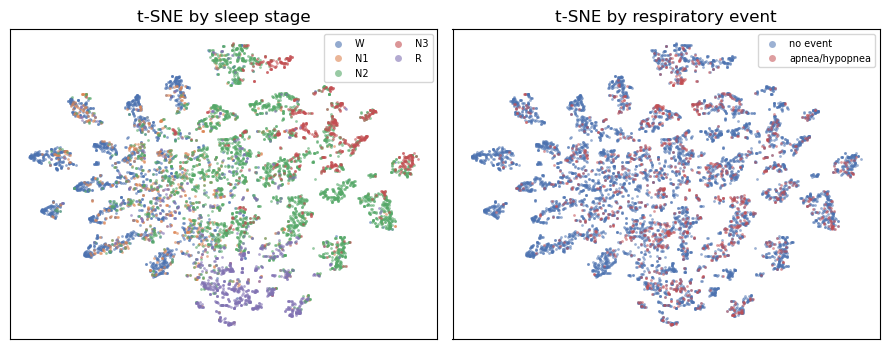

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
os.makedirs("results/revision/figures", exist_ok=True)
h,st,ap = HEAD["emb"]
idx=np.random.RandomState(0).choice(len(h),min(8000,len(h)),replace=False)
hh,ss,aa=h[idx],st[idx],ap[idx]
pca=PCA(2).fit_transform(hh); ts=TSNE(2,perplexity=30,init="pca",random_state=0).fit_transform(PCA(30).fit_transform(hh))
COL=["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3"]
fig,ax=plt.subplots(1,2,figsize=(9,3.6))
for k in range(5): ax[0].scatter(*ts[ss==k].T,s=4,c=COL[k],label=CLS[k],alpha=.6,lw=0)
ax[0].set_title("t-SNE by sleep stage"); ax[0].legend(markerscale=2.5,fontsize=7,ncol=2)
for v,c,l in [(0,"#4C72B0","no event"),(1,"#C44E52","apnea/hypopnea")]: ax[1].scatter(*ts[aa==v].T,s=4,c=c,label=l,alpha=.55,lw=0)
ax[1].set_title("t-SNE by respiratory event"); ax[1].legend(markerscale=2.5,fontsize=7)
for a_ in ax: a_.set_xticks([]); a_.set_yticks([])
fig.tight_layout(); fig.savefig("results/revision/figures/fig_embedding_tsne.pdf",bbox_inches="tight"); plt.show()

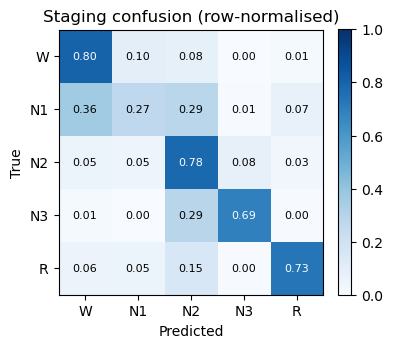

In [14]:
yt,yp,_,_ = HEAD["pred"]
cm=confusion_matrix(yt,yp,labels=range(5)); cmn=cm/cm.sum(1,keepdims=True)
fig,ax=plt.subplots(figsize=(4,3.6)); im=ax.imshow(cmn,cmap="Blues",vmin=0,vmax=1)
for i in range(5):
    for j in range(5): ax.text(j,i,f"{cmn[i,j]:.2f}",ha="center",va="center",color="white" if cmn[i,j]>.5 else "black",fontsize=8)
ax.set_xticks(range(5)); ax.set_xticklabels(CLS); ax.set_yticks(range(5)); ax.set_yticklabels(CLS)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Staging confusion (row-normalised)")
fig.colorbar(im,fraction=0.046); fig.tight_layout(); fig.savefig("results/revision/figures/fig_confusion.pdf",bbox_inches="tight"); plt.show()

## 9. Verification summary
Every number above was produced by a cell that trained the model live on the fixed folds; the
reconstructed "any respiratory event" label matches the trained apnea target exactly. Items
that could not be reproduced are flagged in the verification log rather than carried over.